# 03. The Bayesian structural time-series model, fitted by ADVI

This is the project's Bayesian forecaster, the BSTS: a seasonal regression on
the shared design with a stationary AR([1,2]) error and a heteroskedastic
observation scale. I fit it here by full-rank ADVI. Notebook 04 certifies the
same posterior with NUTS and checks the variational approximation against it.

**Why an AR([1,2]) error.** The regression captures the seasonal and weather
shape; the error carries what it leaves behind. An AR(1) error carries only
the residual level forward and reverts at a fixed rate, so its slope at the
forecast origin is pinned by that one number. An AR(2) error carries the last
two residuals, so the forecast starts from a level and a slope, the curvature
the residual diagnostics ask for (a large negative lag-2 partial
autocorrelation). That is where the model's short-lead sharpness comes from.
The classical ARIMA, left to choose its own order on validation, settles on
AR(1) (notebook 02); here the second lag earns its place through short-lead
sharpness, not by mimicking the baseline.

## The model

On demand standardised over the fitting window, the regression residual
follows a stationary AR([1,2]):

$$
e_t = y_t - x_t^\top \beta, \qquad
e_t - \rho_1 e_{t-1} - \rho_2 e_{t-2} \sim \mathcal{N}(0, \sigma_t^2), \qquad
\log \sigma_t = \gamma_0 + z_t^\top \gamma.
$$

Every symbol:

- $y_t$: standardised demand at half hour $t$.
- $x_t$: the mean-design row (seasonal harmonics, weather, degree days, demand
  lags, holiday, interactions); $\beta$ its regression coefficients.
- $e_t$: the regression residual, the error the AR([1,2]) models.
- $\rho_1, \rho_2$: the AR([1,2]) coefficients.
- $\sigma_t$: the observation scale at $t$; $z_t$ the variance-design row (a
  small daily basis and degree days), with intercept $\gamma_0$ and
  coefficients $\gamma$.

**From partial autocorrelations to AR coefficients.** A partial autocorrelation
(PACF) at a lag is the correlation left at that lag once the shorter lags are
accounted for. Rather than sample the AR coefficients $\rho_1, \rho_2$ directly,
the model samples the two PACFs $\phi_1$ and $\phi_2$, mapped back by the
Durbin-Levinson recursion as $\rho_2 = \phi_2$ and $\rho_1 = \phi_1(1 - \phi_2)$.
The point of PACF space is that an AR(2) is stationary exactly when both PACFs
lie in $(-1, 1)$, so the flat $\phi_2 \sim \mathrm{Uniform}(-1, 1)$ and
$\phi_1 \sim \mathrm{Beta}$ on $(0, 1)$ put every draw inside the stationary
region with no rejection. The first two residuals are drawn from the AR([1,2])'s
stationary law, so the series starts in equilibrium rather than in a transient.

Writing the likelihood on the innovations leaves nothing sequential: the
residuals are one matrix product and the innovations a shifted difference, so
there is no scan and the fit takes seconds.

```mermaid
flowchart TD
  x[x_t mean design: harmonics, weather, degree days, lags, holiday] --> mu[mu_t regression mean = x_t' beta]
  beta[beta regression coefficients] --> mu
  z[z_t variance design: daily basis, degree days] --> sigma[sigma_t observation scale]
  gamma0[gamma0 log-scale intercept] --> sigma
  gamma[gamma log-scale coefficients] --> sigma
  phi1[phi1 lag-1 PACF] --> rho["rho1, rho2: AR([1,2]) coefficients"]
  phi2[phi2 lag-2 PACF] --> rho
  rho --> e["e_t: AR([1,2]) error"]
  sigma --> e
  mu --> y[y_t demand]
  e --> y
```

In [1]:
import os

os.environ.setdefault("JAX_PLATFORMS", "cpu")  # notebook JAX work is light; leave the GPU to fits

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats

from nemforecastdemand.config import load_config
from nemforecastdemand.data.loaders import load_panel, load_splits
from nemforecastdemand.evaluation.metrics import crps_gaussian, crps_samples
from nemforecastdemand.models import bsts
from nemforecastdemand.models.predict import variance_decomposition_innovations
from nemforecastdemand.plotting import (
    MODEL_COLOURS,
    fan_chart,
    format_date_axis,
    palette,
    save_figure,
    setup_style,
)
from nemforecastdemand.splits import rolling_origins
from nemforecastdemand.utils import load_artifact

setup_style()
cfg = load_config()
panel = load_panel(cfg.paths.processed)
splits = load_splits(cfg.paths.processed)
max_lag = max(cfg.features.demand_lags)

fr_arrays, fr_meta = load_artifact(cfg.paths.artifacts / "bsts_innovations_vi_fullrank")
arima_arrays, arima_meta = load_artifact(cfg.paths.artifacts / "arima")

test_origins = rolling_origins(splits["test"].index, panel.index, cfg.origins, cfg.horizon, max_lag)
fit_index = splits["train"].index[max_lag:]
inputs = bsts.prepare_inputs(panel, cfg, fit_index)
y_test = fr_arrays["y_test"]
hours = (np.arange(cfg.horizon) + 1) / 2
AR_SITES = ("phi1", "phi2", "beta", "gamma0", "gamma")
BLUE, ACCENT = palette("demand"), palette("accent")  # BLUE is the canonical BSTS colour


def per_horizon_crps(paths: np.ndarray) -> np.ndarray:
    """Mean CRPS at each lead time from sampled paths, (H,)."""
    return np.stack([crps_samples(y_test[:, h], paths[:, :, h]).mean() for h in range(cfg.horizon)])


pr = cfg.bsts.priors  # prior scales, shared with the fitting scripts

/home/s95717/miniforge3/envs/nem-demand-forecast/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Priors and the prior predictive

Before any data, the priors already say a good deal about what days the model
thinks are possible. The first figure shows each prior on its own. The second
draws whole days from the model with the priors and likelihood alone and no
demand conditioned on, a prior predictive check. The covariates are held at a
real two-day window, the clock and weather given, so every difference between
the traces comes from the sampled parameters and the innovations.

Every prior is set on the standardised scale, so a unit is one standard
deviation of demand or of a design column. That is what makes the magnitudes
below comparable and the choices defensible.

| component | prior | why this centre and scale |
| --- | --- | --- |
| $\phi_1$, lag-1 PACF | $\mathrm{Beta}(8, 2)$ on $(0, 1)$ | Mean $0.8$ puts the mass on the strong positive persistence the diagnostics show; the unit interval rules out negative lag-1 autocorrelation and keeps every draw stationary. |
| $\phi_2$, lag-2 PACF | $\mathrm{Uniform}(-1, 1)$ | Flat across the whole stationary range, taking no prior view on the second lag's sign or size. |
| $\beta$, regression coefficients | $\mathcal{N}(0, 1)$ | Zero centre takes no direction; on the standardised design a unit scale means one covariate standard deviation moves demand by one, weakly informative but enough to regularise the 58 coefficients. |
| $\gamma_0$, log-scale intercept | $\mathcal{N}(-1.5, 0.7)$ | $\exp(-1.5) \approx 0.22$ sets a sensible baseline per-step innovation scale; the $0.7$ scale lets it range by about a factor of two. |
| $\gamma$, log-scale coefficients | $\mathcal{N}(0, 0.25)$ | Zero centre, and a deliberately tight scale because the $\exp$ link compounds; $0.25$ moves the innovation scale by roughly $\exp(\pm 0.25)$ per covariate, enough to learn the daily risk profile but no more. |

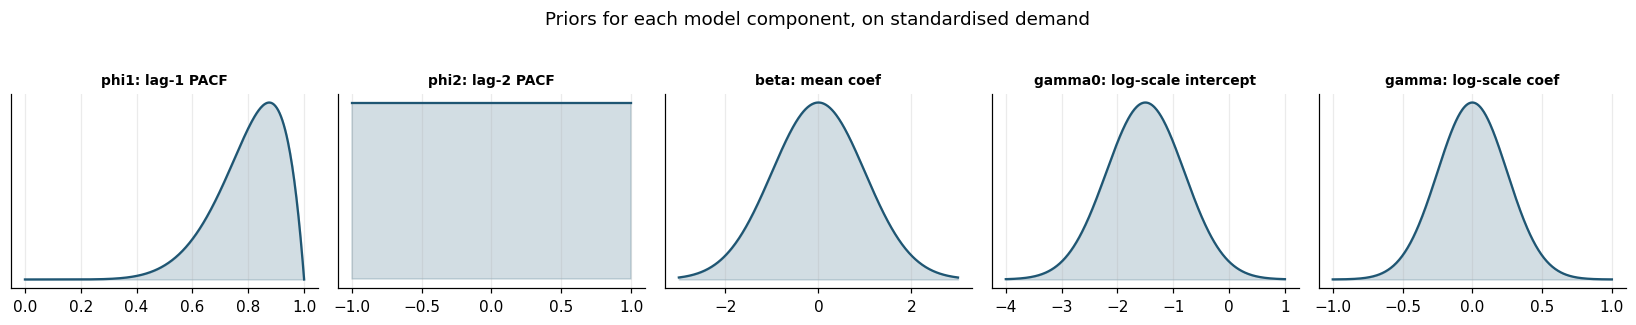

In [2]:
prior_specs = [
    ("phi1: lag-1 PACF", stats.beta(pr.ar_alpha, pr.ar_beta), (0.0, 1.0)),
    ("phi2: lag-2 PACF", stats.uniform(-1.0, 2.0), (-1.0, 1.0)),
    ("beta: mean coef", stats.norm(0.0, pr.coef_scale), (-3.0, 3.0)),
    (
        "gamma0: log-scale intercept",
        stats.norm(pr.var_intercept_loc, pr.var_intercept_scale),
        (-4.0, 1.0),
    ),
    ("gamma: log-scale coef", stats.norm(0.0, pr.var_coef_scale), (-1.0, 1.0)),
]
fig, axes = plt.subplots(1, 5, figsize=(15, 2.8))
for ax, (name, distn, (lo, hi)) in zip(axes, prior_specs, strict=True):
    grid = np.linspace(lo, hi, 400)
    ax.fill_between(grid, distn.pdf(grid), color=BLUE, alpha=0.2)
    ax.plot(grid, distn.pdf(grid), color=BLUE)
    ax.set_title(name, fontsize=9)
    ax.set_yticks([])
fig.suptitle("Priors for each model component, on standardised demand", y=1.04)
fig.tight_layout()
save_figure(fig, "bsts_priors", cfg.paths.figures)
plt.show()

*Takeaway: the lag-1 persistence is pushed positive by design, the lag-2 PACF is left even-handed, and the regression and log-scale coefficients carry broad, weakly informative Gaussians.*

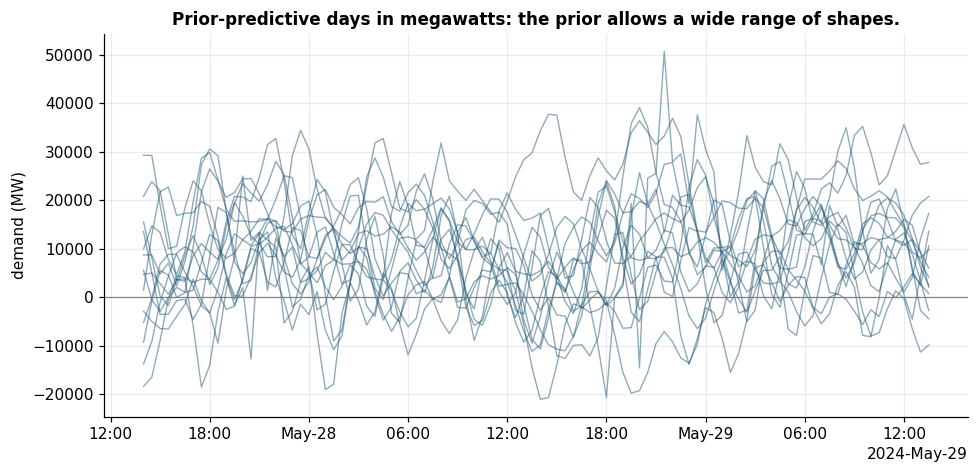

In [3]:
def prior_predictive_days(x_mean_w: np.ndarray, x_var_w: np.ndarray, n_paths: int, seed: int):
    """De-standardised demand days drawn from the prior and likelihood alone.

    The covariate window is held fixed; each path samples the parameters from
    their priors and runs the AR([1,2]) error forward from the same stationary
    anchor the fitted model uses, so the only randomness is the prior draw and
    the innovations.
    """
    rng = np.random.default_rng(seed)
    horizon = x_mean_w.shape[0]
    out = np.empty((n_paths, horizon))
    for s in range(n_paths):
        phi1 = rng.beta(pr.ar_alpha, pr.ar_beta)
        phi2 = rng.uniform(-1.0, 1.0)
        rho1, rho2 = phi1 * (1.0 - phi2), phi2
        beta = rng.normal(0.0, pr.coef_scale, size=x_mean_w.shape[1])
        gamma0 = rng.normal(pr.var_intercept_loc, pr.var_intercept_scale)
        gamma = rng.normal(0.0, pr.var_coef_scale, size=x_var_w.shape[1])
        sigma = np.exp(np.clip(gamma0 + x_var_w @ gamma, -8.0, 3.0))
        e = np.empty(horizon)
        var0 = sigma[0] ** 2 * (1.0 - rho2) / ((1.0 + rho2) * ((1.0 - rho2) ** 2 - rho1**2))
        sd0 = np.sqrt(var0)
        lag1_corr = rho1 / (1.0 - rho2)
        e[0] = rng.normal(0.0, sd0)
        e[1] = rng.normal(lag1_corr * e[0], sd0 * np.sqrt(1.0 - lag1_corr**2))
        for t in range(2, horizon):
            e[t] = rho1 * e[t - 1] + rho2 * e[t - 2] + rng.normal(0.0, sigma[t])
        out[s] = x_mean_w @ beta + e
    return inputs.y_loc + inputs.y_scale * out


aest = inputs.index.tz_convert("Australia/Brisbane")
midnights = np.where((aest.hour == 0) & (aest.minute == 0))[0]
w0 = int(midnights[len(midnights) // 2])  # a midnight-anchored two-day window mid-training
window = slice(w0, w0 + 2 * cfg.horizon)
clock = aest[window]

prior_days = prior_predictive_days(inputs.x_mean[window], inputs.x_var[window], 14, cfg.seed)

fig, ax = plt.subplots(figsize=(9, 4.4))
ax.plot(clock, prior_days.T, color=BLUE, alpha=0.5, lw=0.9)
ax.axhline(0.0, color="grey", lw=0.8)
ax.set_title("Prior-predictive days in megawatts: the prior allows a wide range of shapes.")
ax.set_ylabel("demand (MW)")
format_date_axis(ax)
fig.tight_layout()
save_figure(fig, "bsts_prior_predictive", cfg.paths.figures)
plt.show()

*Takeaway: the weak coefficient priors barely pin the overall level, so prior-predictive days roam far in megawatts and some even go negative, yet the harmonics, the AR([1,2]) error and the heteroskedastic scale still give each day a plausible shape; the data does the rest, which is why the posterior coefficients shrink so hard.*

## ADVI: ELBO decomposed

ADVI maximises the evidence lower bound, the ELBO, over a Gaussian variational
approximation $q$, and that bound splits exactly into two readable pieces:

$$ \mathrm{ELBO} = \underbrace{\mathbb{E}_q[\log p(y, \theta)]}_{\text{energy}}
   + \underbrace{\mathbb{H}[q]}_{\text{entropy}}, $$

the energy (how well $q$ sits under the model) and the entropy (how spread out
it stays). Both the ELBO and the energy cover most of their distance in the
first few hundred steps, so a linear axis hides the small late movements that
actually decide convergence. The panels below instead plot each one's remaining
gap to its converged plateau on a log axis, which keeps that tail legible across
orders of magnitude. The entropy keeps its own linear axis, since its job is to
show it settles at a finite spread rather than collapsing toward a spike, the
signature of a variational fit gone under-dispersed. I use a full-rank
approximation (`AutoMultivariateNormal`), whose covariance can carry the
correlations between the persistence, the variance head and the regression.

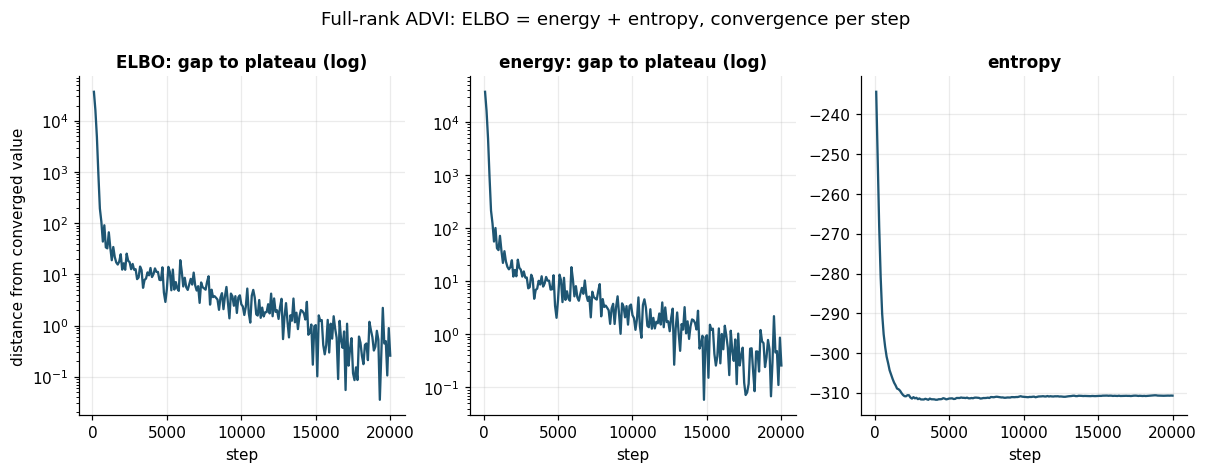

In [4]:
steps = fr_arrays["elbo_steps"]
plateau_window = 20  # final checkpoints define the converged value


def gap_to_plateau(series: np.ndarray) -> np.ndarray:
    """Absolute distance from each step to the converged (final-window) value."""
    return np.abs(series[-plateau_window:].mean() - series)


fig, axes = plt.subplots(1, 3, figsize=(13, 4))
axes[0].plot(steps, gap_to_plateau(fr_arrays["elbo"]), color=BLUE)
axes[1].plot(steps, gap_to_plateau(fr_arrays["energy"]), color=BLUE)
axes[2].plot(steps, fr_arrays["entropy"], color=BLUE)
for ax in axes[:2]:
    ax.set_yscale("log")
for ax, title in zip(
    axes, ("ELBO: gap to plateau (log)", "energy: gap to plateau (log)", "entropy"), strict=True
):
    ax.set_title(title)
    ax.set_xlabel("step")
axes[0].set_ylabel("distance from converged value")
fig.suptitle("Full-rank ADVI: ELBO = energy + entropy, convergence per step", y=1.03)
save_figure(fig, "elbo_decomposition", cfg.paths.figures)
plt.show()

*Takeaway: the ELBO and energy gaps fall by orders of magnitude and flatten into a low jitter floor, a clean convergence, while the entropy settles at a finite spread rather than collapsing, so the approximation is not silently under-dispersing.*

In [5]:
def plateau_drift(elbo: np.ndarray, window: int = 20) -> str:
    """Relative ELBO drift between the last two checkpoint windows."""
    recent = elbo[-window:].mean()
    previous = elbo[-2 * window : -window].mean()
    return f"{abs(recent - previous) / abs(previous):.2%}"


pd.DataFrame(
    {
        "BSTS-ADVI-FR": {
            "final ELBO": fr_meta["final_elbo"],
            "plateau drift, last 2k steps": plateau_drift(fr_arrays["elbo"]),
            "fit seconds": fr_meta["timings_seconds"]["fit_seconds"],
            "device": fr_meta["device"],
        }
    }
).T

,final ELBO,"plateau drift, last 2k steps",fit seconds,device
BSTS-ADVI-FR,47815.0625,0.00%,5.860699,gpu


*Takeaway: the fit converges (drift under a fraction of a percent) in seconds, because the innovations form has no sequential scan in the gradient.*

## How far the data moved each prior

With the fit in hand, placing each prior (top row) above its full-rank ADVI
posterior (bottom row) shows how much the data had to say about each parameter.
Two years of half-hourly demand pin the regression and log-scale coefficients to
spikes far narrower than their priors, settle the persistence in the
deep-positive regime, and pull the lag-2 PACF firmly negative from its flat
prior, the slope-carrying term the diagnostics asked for. The blue line on each
prior marks where its posterior mean landed; the posterior itself is drawn below
on its own zoomed scale, because against the prior's wide axis it would collapse
to a single invisible spike.

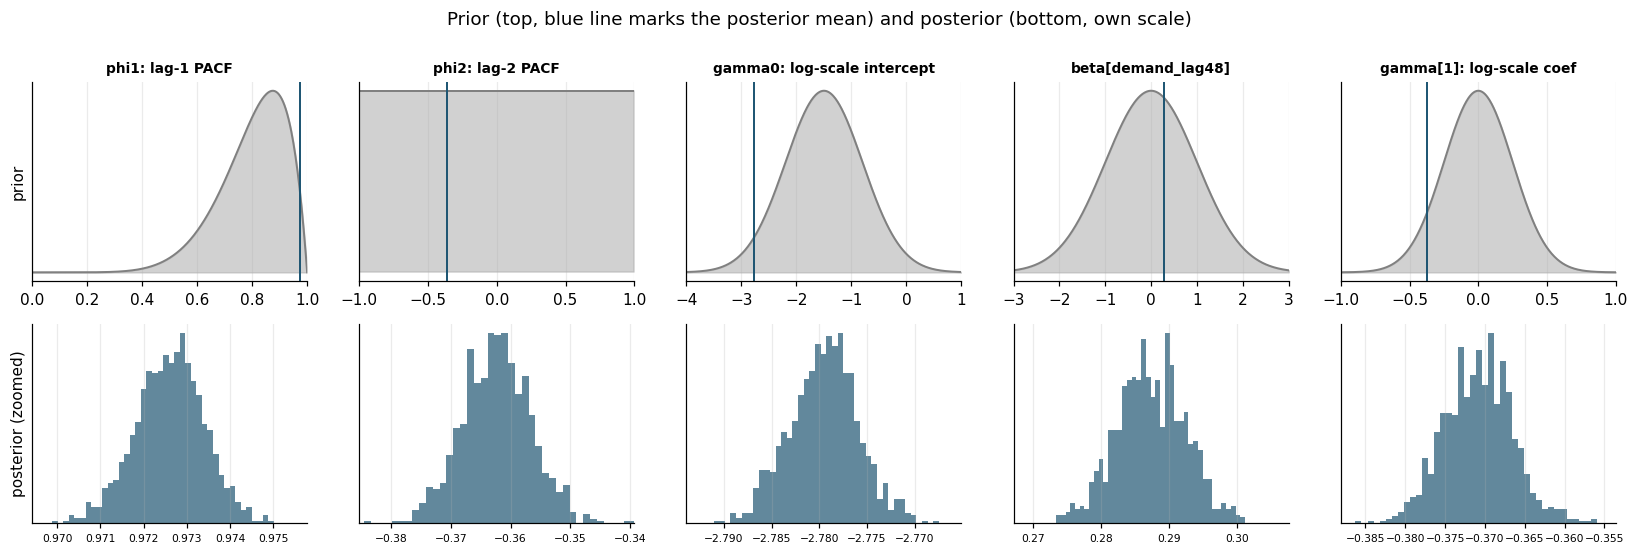

In [6]:
b_idx = int(np.abs(fr_arrays["draw_beta"].mean(0)).argmax())  # most-moved mean coefficient
g_idx = int(np.abs(fr_arrays["draw_gamma"].mean(0)).argmax())  # most-moved log-scale coefficient
post_specs = [
    ("phi1: lag-1 PACF", fr_arrays["draw_phi1"], stats.beta(pr.ar_alpha, pr.ar_beta), (0.0, 1.0)),
    ("phi2: lag-2 PACF", fr_arrays["draw_phi2"], stats.uniform(-1.0, 2.0), (-1.0, 1.0)),
    (
        "gamma0: log-scale intercept",
        fr_arrays["draw_gamma0"],
        stats.norm(pr.var_intercept_loc, pr.var_intercept_scale),
        (-4.0, 1.0),
    ),
    (
        f"beta[{inputs.columns[b_idx]}]",
        fr_arrays["draw_beta"][:, b_idx],
        stats.norm(0.0, pr.coef_scale),
        (-3.0, 3.0),
    ),
    (
        f"gamma[{g_idx}]: log-scale coef",
        fr_arrays["draw_gamma"][:, g_idx],
        stats.norm(0.0, pr.var_coef_scale),
        (-1.0, 1.0),
    ),
]
fig, axes = plt.subplots(2, 5, figsize=(15, 5))
for col, (name, draws, prior, (lo, hi)) in enumerate(post_specs):
    grid = np.linspace(lo, hi, 400)
    top, bottom = axes[0, col], axes[1, col]
    top.fill_between(grid, prior.pdf(grid), color="0.7", alpha=0.6)
    top.plot(grid, prior.pdf(grid), color="0.5", lw=1.3)
    top.axvline(draws.mean(), color=BLUE, lw=1.3)  # where the posterior landed
    top.set_xlim(lo, hi)
    top.set_title(name, fontsize=9)
    # the posterior is far too sharp for the prior's axis, so zoom to its own range
    half = max(4.0 * draws.std(), 1e-3)
    bottom.hist(draws, bins=40, density=True, color=BLUE, alpha=0.7)
    bottom.set_xlim(draws.mean() - half, draws.mean() + half)
    bottom.tick_params(axis="x", labelsize=7)
    top.set_yticks([])
    bottom.set_yticks([])
axes[0, 0].set_ylabel("prior")
axes[1, 0].set_ylabel("posterior (zoomed)")
fig.suptitle(
    "Prior (top, blue line marks the posterior mean) and posterior (bottom, own scale)", y=1.0
)
fig.tight_layout()
save_figure(fig, "bsts_prior_posterior", cfg.paths.figures)
plt.show()

*Takeaway: every component sharpens against its prior, most dramatically the regression coefficients, so the data strongly identifies the model and the posterior is nowhere near simply echoing the prior.*

## Persistence and the learned variance profile

The lag-1 coefficient lands deep in the persistent regime and the lag-2
coefficient comes out firmly negative, the slope-carrying term the residual
diagnostics asked for. The variance head reproduces the daily risk profile:
narrow bands through the small hours, wide bands across the afternoon and
evening ramps. The choice of a heteroskedastic scale is justified straight
from the data in the EDA (notebook 01).

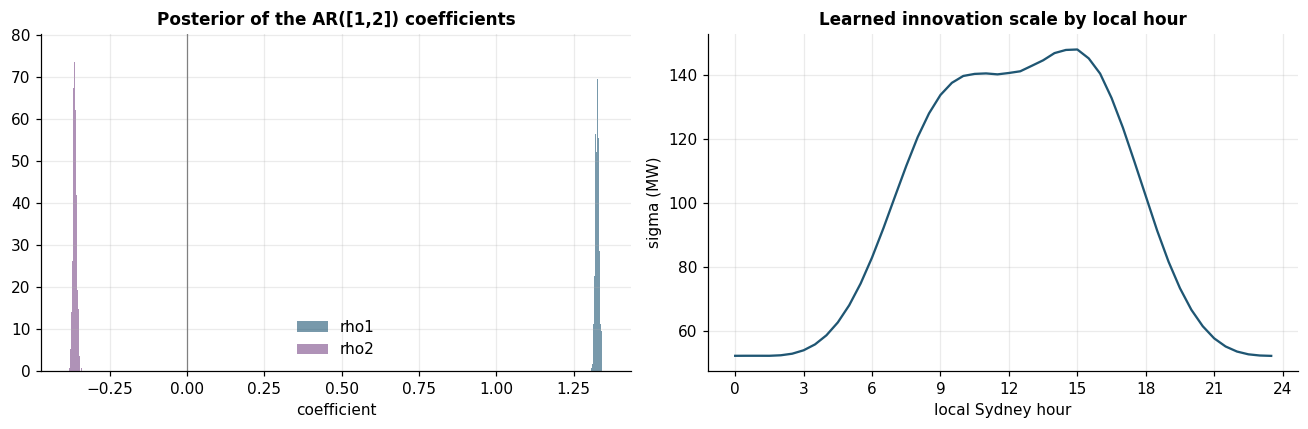

In [7]:
def ar_coeffs(arrays: dict) -> dict[str, np.ndarray]:
    """AR([1,2]) coefficients and the variance intercept from a fit's draws."""
    rho1 = arrays["draw_phi1"] * (1.0 - arrays["draw_phi2"])
    return {"rho1": rho1, "rho2": arrays["draw_phi2"], "gamma0": arrays["draw_gamma0"]}


local_hour = fit_index.tz_convert("Australia/Sydney")
hour_frac = local_hour.hour + local_hour.minute / 60

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fr_coeffs = ar_coeffs(fr_arrays)
for name, colour in (("rho1", BLUE), ("rho2", ACCENT)):
    axes[0].hist(fr_coeffs[name], bins=40, density=True, alpha=0.6, color=colour, label=name)
axes[0].axvline(0.0, color="grey", lw=0.8)
axes[0].set_title("Posterior of the AR([1,2]) coefficients")
axes[0].set_xlabel("coefficient")
axes[0].legend()

gamma0 = fr_arrays["draw_gamma0"][:, None]
gamma = fr_arrays["draw_gamma"]
log_sigma = gamma0 + gamma @ inputs.x_var.T
sigma_mw = np.exp(log_sigma) * inputs.y_scale
profile = pd.DataFrame({"hour": hour_frac, "sigma": sigma_mw.mean(axis=0)}).groupby("hour").mean()
axes[1].plot(profile.index, profile["sigma"], color=BLUE)
axes[1].set_title("Learned innovation scale by local hour")
axes[1].set_xlabel("local Sydney hour")
axes[1].set_ylabel("sigma (MW)")
axes[1].set_xticks(np.arange(0, 25, 3))
fig.tight_layout()
save_figure(fig, "bsts_coeffs_and_variance", cfg.paths.figures)
plt.show()

*Takeaway: a persistent lag-1 and a firmly negative lag-2 give the error its origin slope, and the learned scale is narrow overnight and wide across the evening ramp.*

## Forecasts

Each forecast carries the two observed origin residuals forward under that
draw's AR([1,2]) coefficients, a level and a slope rather than just a decaying
level, with the innovations accumulating at the covariate-driven scale. That
gives one coherent 48-step path per draw. The CRPS uses the energy-form sample
estimator, unit-tested against the analytic Gaussian form.

In [8]:
crps_rows = {
    "BSTS-ADVI-FR": float(
        np.mean(
            [
                crps_samples(y_test[i], fr_arrays["forecast_paths"][:, i, :]).mean()
                for i in range(y_test.shape[0])
            ]
        )
    ),
    "ARIMA": float(
        crps_gaussian(
            arima_arrays["y_test"], arima_arrays["forecast_mean"], arima_arrays["forecast_sd"]
        ).mean()
    ),
}
pd.Series(crps_rows, name="test CRPS (MW), archived forecast weather").to_frame().round(1)

,"test CRPS (MW), archived forecast weather"
BSTS-ADVI-FR,272.4
ARIMA,258.0


*Takeaway: on overall CRPS the BSTS and ARIMA are close; the difference is where each wins across the horizon.*

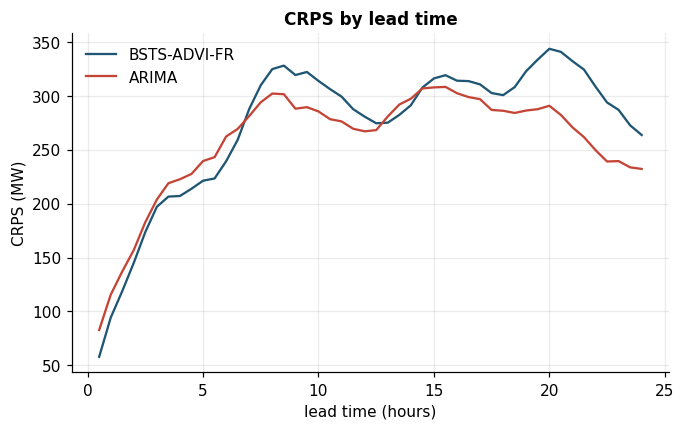

In [9]:
ar_curve = per_horizon_crps(fr_arrays["forecast_paths"])
arima_curve = np.stack(
    [
        crps_gaussian(
            y_test[:, h], arima_arrays["forecast_mean"][:, h], arima_arrays["forecast_sd"][:, h]
        ).mean()
        for h in range(cfg.horizon)
    ]
)
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(hours, ar_curve, color=BLUE, label="BSTS-ADVI-FR")
ax.plot(hours, arima_curve, color=MODEL_COLOURS["ARIMA"], label="ARIMA")
ax.set_xlabel("lead time (hours)")
ax.set_ylabel("CRPS (MW)")
ax.set_title("CRPS by lead time")
ax.legend()
save_figure(fig, "bsts_horizon_crps", cfg.paths.figures)
plt.show()

*Takeaway: the BSTS is much sharper in the first hours, where the AR([1,2]) carry reads the origin residuals; ARIMA catches up at long lead.*

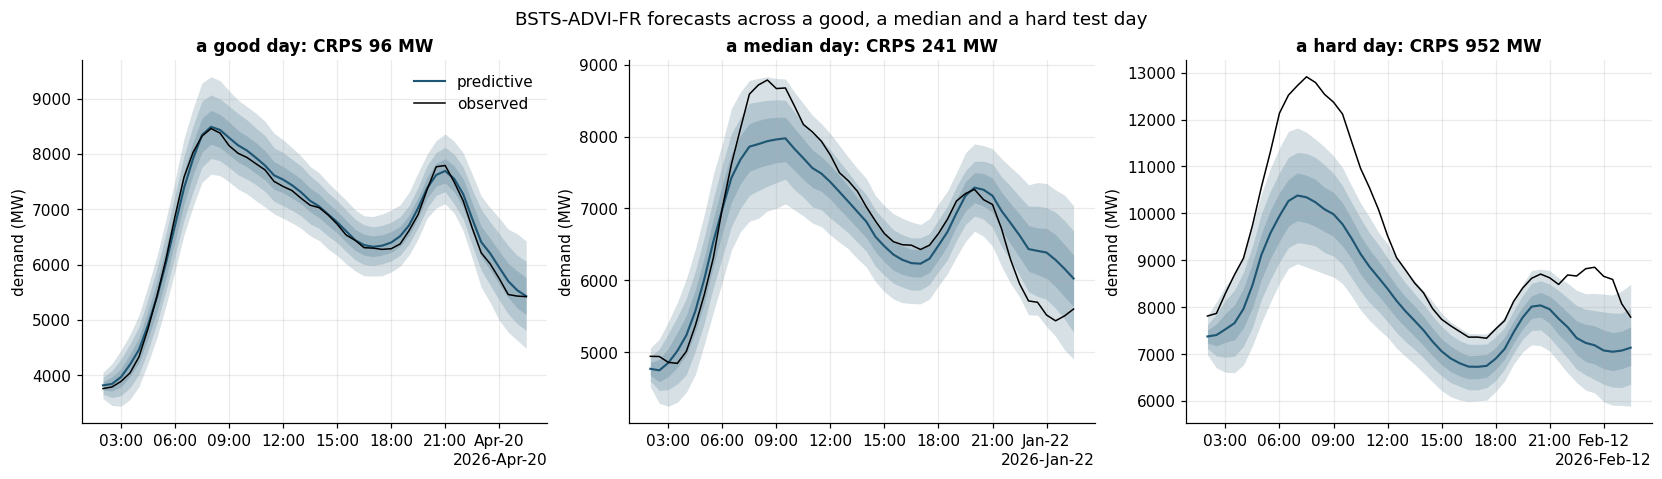

In [10]:
fr_paths = fr_arrays["forecast_paths"]
daily_crps = np.stack(
    [crps_samples(y_test[i], fr_paths[:, i, :]).mean() for i in range(y_test.shape[0])]
)
order = np.argsort(daily_crps)
picks = [
    ("a good day", int(order[0])),
    ("a median day", int(order[len(order) // 2])),
    ("a hard day", int(order[-1])),
]

fig, axes = plt.subplots(1, 3, figsize=(15, 4), constrained_layout=True)
for ax, (label, pos) in zip(axes, picks, strict=True):
    origin = test_origins[pos]
    index = pd.date_range(origin, periods=cfg.horizon, freq="30min")
    fan_chart(ax, index, samples=fr_paths[:, pos, :], colour=BLUE, label="predictive")
    ax.plot(
        index.tz_convert("Australia/Brisbane"), y_test[pos], color="black", lw=1.0, label="observed"
    )
    ax.set_title(f"{label}: CRPS {daily_crps[pos]:.0f} MW")
    ax.set_ylabel("demand (MW)")
axes[0].legend()
fig.suptitle("BSTS-ADVI-FR forecasts across a good, a median and a hard test day", y=1.05)
save_figure(fig, "bsts_vi_fan_charts", cfg.paths.figures)
plt.show()

*Takeaway: the bands track the observed across regimes; even the hard day is an extreme peak the predictive widens to acknowledge rather than misses outright.*

## Decomposed Predictive Variance

Conditional on a draw the h-step predictive is Gaussian, so the law of total
variance splits the predictive into two exact parts. The origin residuals are
observed, so there is no state term:

- **parameter** (epistemic): variance across draws of the conditional mean,
  the uncertainty more data would shrink;
- **alea** (aleatoric): the accumulated AR-carried noise. *Alea* is the chance
  term (Latin for a die), the irreducible part no amount of data removes.

The epistemic share doubles as an inference diagnostic, because an
under-dispersed approximation has to understate it. That is the check notebook
04 runs against NUTS.

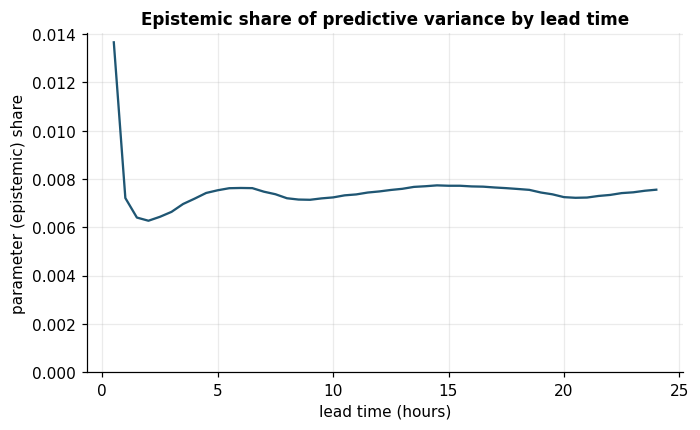

In [11]:
ar_decomp = variance_decomposition_innovations(
    {site: fr_arrays[f"draw_{site}"] for site in AR_SITES}, inputs, panel, cfg, test_origins
)
total = ar_decomp["parameter"] + ar_decomp["innovation"]

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(hours, (ar_decomp["parameter"] / total).mean(axis=0), color=BLUE)
ax.set_xlabel("lead time (hours)")
ax.set_ylabel("parameter (epistemic) share")
ax.set_ylim(0, None)
ax.set_title("Epistemic share of predictive variance by lead time")
save_figure(fig, "innovations_variance_decomposition", cfg.paths.figures)
plt.show()

*Takeaway: the epistemic share is small at every lead, so with two years of training the parameters are well pinned and almost all predictive uncertainty is irreducible.*

In [12]:
pd.DataFrame(
    {
        "BSTS-ADVI-FR": {
            "parameter share": float((ar_decomp["parameter"] / total).mean()),
            "alea share": float((ar_decomp["innovation"] / total).mean()),
            "mean predictive sd (MW)": float(np.sqrt(total.mean())),
        }
    }
).T.round(3)

,parameter share,alea share,mean predictive sd (MW)
BSTS-ADVI-FR,0.007,0.993,452.074


*Takeaway: the alea (aleatoric) term dominates the predictive variance, confirming the epistemic share read off the curve above.*

## Summary

- The BSTS is a seasonal regression with a stationary AR([1,2]) error and a
  heteroskedastic scale. The lag-2 term gives the error a slope at the origin
  that an AR(1) error cannot carry, which is where the short-lead sharpness
  comes from.
- Full-rank ADVI fits it in seconds and converges cleanly, with no sign of the
  entropy collapse that signals under-dispersion.
- The posterior is correlated, so a full-rank approximation is the right
  choice; notebook 04 measures how far it sits from the NUTS reference.
- The predictive variance splits into a small epistemic part and a dominant
  irreducible innovation part, and that split is the inference diagnostic
  notebook 04 audits.